In [19]:
import pandas as pd
import seaborn as sns
from sqlalchemy import engine
from pandasql import sqldf

pysqldf = lambda q: sqldf(q, globals())

In [4]:
import os
print(os.getcwd())


d:\Archivos\Desktop\hola


In [5]:
df = pd.read_csv("data.csv")

In [6]:
df

,keyword,campaña,clicks,impresiones,costo,conversiones
0,zapatos mujer,Campaña A,120.0,5000,200,10.0
1,zapatos mujer,Campaña A,120.0,5000,200,10.0
2,zapatillas hombre,Campaña B,90.0,4000,150,8.0
3,botas cuero,Campaña C,60.0,3000,120,5.0
4,sandalias verano,Campaña A,80.0,3500,140,7.0
5,zapatos mujer,Campaña B,110.0,4800,190,9.0
6,zapatillas hombre,Campaña B,NaN,4200,160,8.0
7,botas cuero,Campaña C,60.0,3000,120,5.0
8,zapatillas running,Campaña D,70.0,3100,130,NaN
9,pantuflas,Campaña D,50.0,2000,90,4.0


In [7]:
df.shape

(11, 6)

In [8]:
df.describe()

,clicks,impresiones,costo,conversiones
count,10.000000,11.000000,11.000000,10.000000
mean,84.000000,3736.363636,149.090909,7.300000
std,25.473298,960.492298,35.624302,2.110819
min,50.000000,2000.000000,90.000000,4.000000
25%,62.500000,3050.000000,125.000000,5.500000
50%,80.000000,3500.000000,140.000000,7.500000
75%,105.000000,4500.000000,175.000000,8.750000
max,120.000000,5000.000000,200.000000,10.000000


In [9]:
df['keyword'].duplicated().sum()

np.int64(5)

In [10]:
df[df['keyword'].duplicated(keep=False)]

,keyword,campaña,clicks,impresiones,costo,conversiones
0,zapatos mujer,Campaña A,120.0,5000,200,10.0
1,zapatos mujer,Campaña A,120.0,5000,200,10.0
2,zapatillas hombre,Campaña B,90.0,4000,150,8.0
3,botas cuero,Campaña C,60.0,3000,120,5.0
4,sandalias verano,Campaña A,80.0,3500,140,7.0
5,zapatos mujer,Campaña B,110.0,4800,190,9.0
6,zapatillas hombre,Campaña B,NaN,4200,160,8.0
7,botas cuero,Campaña C,60.0,3000,120,5.0
10,sandalias verano,Campaña A,80.0,3500,140,7.0


In [11]:
df = df.drop_duplicates(subset=['keyword'])

In [12]:
df['keyword'].duplicated().sum()

np.int64(0)

In [13]:
df = df.dropna(subset=['clicks'])

In [14]:
df

,keyword,campaña,clicks,impresiones,costo,conversiones
0,zapatos mujer,Campaña A,120.0,5000,200,10.0
2,zapatillas hombre,Campaña B,90.0,4000,150,8.0
3,botas cuero,Campaña C,60.0,3000,120,5.0
4,sandalias verano,Campaña A,80.0,3500,140,7.0
8,zapatillas running,Campaña D,70.0,3100,130,NaN
9,pantuflas,Campaña D,50.0,2000,90,4.0


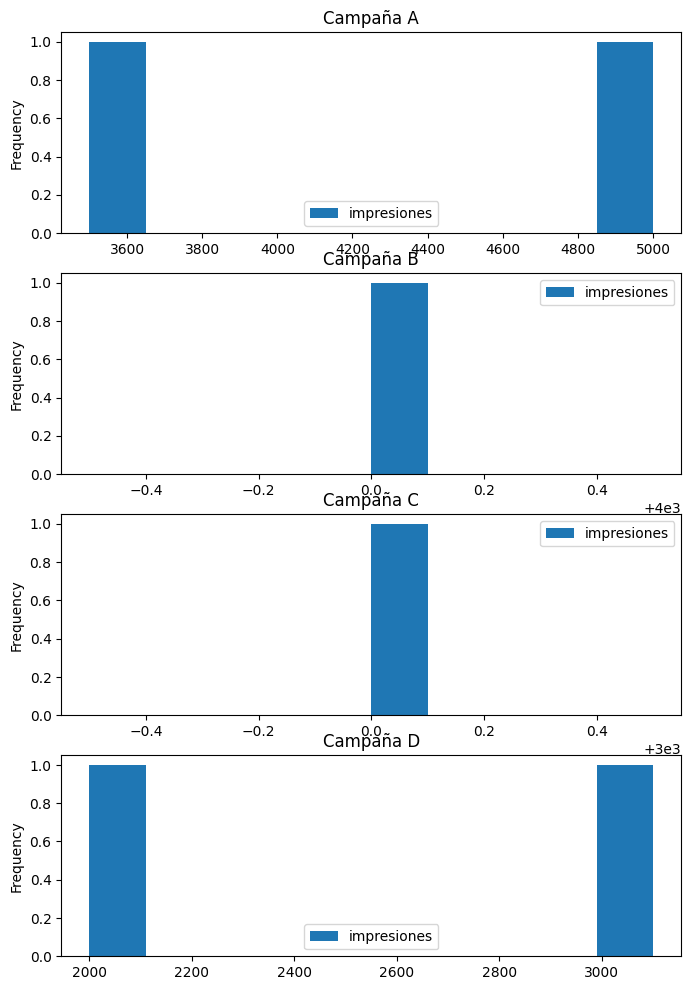

In [15]:
ax = df.plot.hist(column=['impresiones'], by= 'campaña', bins=10, figsize=(8, 12))

In [16]:
df = df.dropna()

<Axes: xlabel='campaña', ylabel='clicks'>

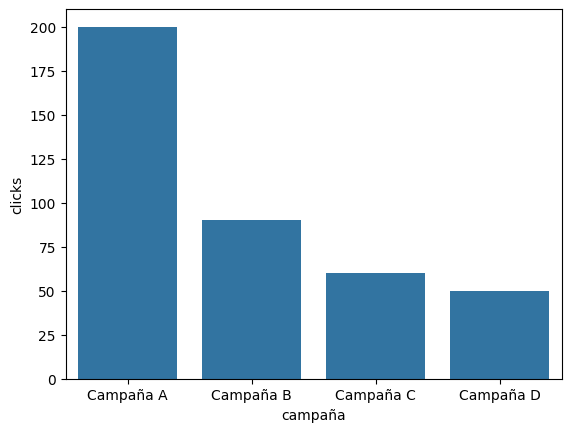

In [17]:
sns.barplot(data=df, x= "campaña", y="clicks", errorbar=None, estimator=sum)


In [18]:
df

,keyword,campaña,clicks,impresiones,costo,conversiones
0,zapatos mujer,Campaña A,120.0,5000,200,10.0
2,zapatillas hombre,Campaña B,90.0,4000,150,8.0
3,botas cuero,Campaña C,60.0,3000,120,5.0
4,sandalias verano,Campaña A,80.0,3500,140,7.0
9,pantuflas,Campaña D,50.0,2000,90,4.0


In [20]:
q = """
SELECT
keyword,
campaña,
clicks,
impresiones,
costo,
conversiones
from df
where impresiones >= 3500
"""
df_export = pysqldf(q)

In [21]:
df_export.to_csv("datos_procesados.csv")

In [22]:
df_export

,keyword,campaña,clicks,impresiones,costo,conversiones
0,zapatos mujer,Campaña A,120.0,5000,200,10.0
1,zapatillas hombre,Campaña B,90.0,4000,150,8.0
2,sandalias verano,Campaña A,80.0,3500,140,7.0
